# The 10-14% mortgage-REIT dividend — real income, or your own money handed back? 🏚️
### The mREIT carry machine, taken apart in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Open any income-investing screen and there they are: mortgage REITs, yielding **10, 12, 14 percent**. Annaly. AGNC. The sector ETF, REM. The pitch is seductive: these companies borrow cheap, buy government-backed mortgage bonds, and pass the levered interest spread to you as a fat dividend. *"Yes, the price bounces around — but the income is real."*

Here's the strange thing: **both halves of that sentence are true.** The income *is* real — we measure it below at 10-16% a year, and it's one of the most statistically solid numbers on this desk. And yet holding the sector fund for nineteen years turned $100 into **$80.50**. This notebook is about how both things can be true at once.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the benchmark regression and the robustness grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> 🔬 **For the quants:** the headline leg is **REM**, an index *fund* — every mREIT blow-up is inside its tape, so the sector number is not survivor-biased. The single names (NLY, AGNC) are the two biggest *survivors* and are quoted as colour. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mreit_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TR, PX = data.load_real()
    MTR, MPX = st.aligned_monthly(TR, PX, ["REM", "IEF", "SPY", "BIL"])
else:
    TR = PX = MTR = MPX = None
print("real mREIT cache present:", HAVE_REAL,
      "| months:", (0 if MTR is None else len(MTR)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-06-30', 'end': '2026-06-30', 'n_months': 229, 'years': 19.1, 'as_of': '2026-06-30', 'fingerprint': '3b2ec2fc7dd3', 'decomp': {'REM': (229, 84.69, 10.65, 18.09, -1.13, -10.96, 80.5, 10.9), 'NLY': (229, 103.04, 13.09, 23.01, 7.52, -5.18, 399.0, 36.2), 'AGNC': (217, 121.46, 15.59, 17.8, 11.8, -3.22, 751.4, 55.3)}, 'perf': {'REM': (-1.13, 24.17, 0.04, -67.44), 'IEF': (3.32, 6.7, 0.32, -23.15), 'SPY': (10.68, 15.58, 0.64, -50.78), 'BIL': (1.36, 0.56, None, -0.42)}, 'rem_excess_bps': 7.78, 'rem_excess_t': 0.18, 'race': {'REM': (-87.62, -10.02, -2.5, 0.42, 1.91, 1.05, 6.8, 0.46, -1.13, 12.07, -67.4, -49.7, -3.01), 'NLY': (-8.11, -0.97, -0.22, 1.05, 4.06, 0.78, 4.34, 0.31, 7.52, 11.03, -45.8, -33.4, -0.27), 'AGNC': (18.83, 2.28, 0.43, 1.2, 4.41, 0.82, 5.03, 0.32, 11.8, 12.03, -48.1, -36.0, 0.51)}, 'robust_lags': [(3, -87.62, -2.32), (6, -87.62, -2.5), (12, -87.62, -2.78)], 'exgfc': {'alpha_bps': -76.48, 't': -1.93, 'div_ann': 10.33, 'div_t': 17.0, 'tr_cagr': 4.28, 'px_cagr': -5.78}, 'crises': [('GFC 2007-09', -74.7, -40.9, -31.0, -55.2, -6.2), ('Taper tantrum 2013', -24.8, -34.6, -36.9, -5.6, -9.1), ('COVID 2020', -68.5, -60.1, -51.8, -33.7, -4.7), ('Rate shock 2022', -40.3, -47.8, -48.2, -24.5, -17.4)], 'syn': [(0.0, 0.0, 1.49, 0.71, -6.45, -0.35), (100.0, -70.0, 101.49, 48.21, -76.45, -4.15)]}


real mREIT cache present: True | months: 229


## The answer first

| Question | Answer |
|---|---|
| Is the 10-14% dividend real? | **Yes.** The sector fund actually paid out **10.7% a year** in dividends for 19 straight years — measured, not advertised. The flagships paid 13-16%. This part of the pitch is honest. |
| Did the income make you rich? | **No.** $100 in the sector fund in 2007, every dividend reinvested, became **$80** by 2026 — *less than T-bills* — because the share price itself eroded **-11% a year**. |
| So where did the coupon come from? | Largely **out of the price**. The fund handed you ~10.65%/yr with one hand while the NAV leaked ~11%/yr out the other. $100 of *price* became **$11**. |
| Was it at least safe on the way? | **The opposite.** It crashed **harder than the stock market** in 2008 (−75%), 2013, 2020 (−68% in eight weeks) *and* 2022. |

> The mortgage-REIT coupon is a genuine *carry trade* — real cash, harvested monthly — strapped to a vehicle that consumes principal and blows up exactly when everything else does. Real carry, mirage vehicle.

## 1 · The claim

> *"Mortgage REITs pay 10-14%. They borrow at short rates, buy government-guaranteed mortgage bonds, lever the spread 6-8×, and are legally required to pay ~90% of the income out to you. The price is volatile, sure — but the dividend stream is real money, and if you harvest it, the carry compounds."*

This is the backbone of a thousand "retire on dividends" model portfolios. And unlike most desk folklore, the *mechanism* is real: an agency mREIT genuinely is a levered bond-carry book, and the coupon genuinely lands in your brokerage account. The question is what happens to the *rest* of your money while it does.

## 2 · So what?

If the pitch were right, a retiree could replace bonds with mREITs and quadruple the income. If it's wrong the way we suspect, the 10-14% is partly **your own capital handed back with a yield label on it** — and the "bond substitute" carries *stock-crash* risk concentrated in the worst weeks of the century. This is the third asset the desk has caught in the same costume: pipelines ([Study 341](../../341-mlp-pipelines/README.md)) and private-credit BDCs ([Study 342](../../342-bdc-yield/README.md)) ran the same play. The mortgage flavour is the purest, because here the income really *is* a carry trade — which means it's short liquidity, and liquidity is what vanishes in a crisis.

## 3 · How would we even know?

One trick does all the work: we download every price series **twice** — once including reinvested dividends (**total return**: what you actually got) and once as the raw share price (**price-only**: what happened to your capital). Subtract them month by month and the difference is exactly the **dividend stream** — the carry the pitch sells.

Then three questions:
1. **Is the carry real?** Average the dividend component; test it hard.
2. **What did it cost?** Look at what the price leg did while the coupon flowed.
3. **Could you have done better with a bare-hands copy?** Compare the fund to a simple mix of Treasury bonds + stocks with the *same* measured risk (the quants notebook runs that regression). If the packaged carry loses to the DIY version, the package is the problem.

## 4 · The teardown — let's actually look

**First, the whole story in one picture:** $100 in the sector fund, 2007→2026 — with dividends reinvested (what you got) vs the share price alone (what happened to your capital), against boring stocks and boring Treasuries.

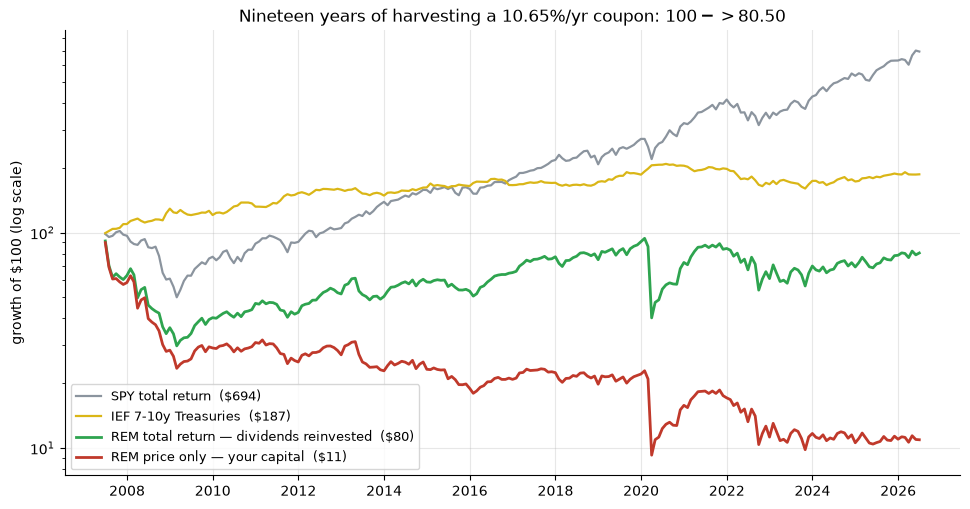

$100 -> REM TR $80.5 | REM price-only $10.9 | SPY $693.7 | IEF $186.6


In [2]:
if HAVE_REAL:
    w = {c: (1.0 + MTR[c]).cumprod() * 100 for c in ['REM','SPY','IEF']}
    w_px = (1.0 + MPX['REM']).cumprod() * 100
    fig, ax = plt.subplots(figsize=(9.8, 5.2))
    ax.plot(w['SPY'], c=GREY, lw=1.6, label=f"SPY total return  (${w['SPY'].iloc[-1]:.0f})")
    ax.plot(w['IEF'], c=AMBER, lw=1.6, label=f"IEF 7-10y Treasuries  (${w['IEF'].iloc[-1]:.0f})")
    ax.plot(w['REM'], c=GREEN, lw=2.0, label=f"REM total return — dividends reinvested  (${w['REM'].iloc[-1]:.0f})")
    ax.plot(w_px, c=RED, lw=2.0, label=f"REM price only — your capital  (${w_px.iloc[-1]:.0f})")
    ax.set_yscale('log'); ax.set_ylabel('growth of $100 (log scale)')
    ax.set_title('Nineteen years of harvesting a 10.65%/yr coupon: $100 -> $80.50')
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"$100 -> REM TR ${w['REM'].iloc[-1]:.1f} | REM price-only ${w_px.iloc[-1]:.1f} | "
          f"SPY ${w['SPY'].iloc[-1]:.1f} | IEF ${w['IEF'].iloc[-1]:.1f}")
else:
    print('cache missing - frozen numbers:', '$100 -> REM TR $%.1f, price-only $%.1f'
          % (R['decomp']['REM'][6], R['decomp']['REM'][7]))

The green line is the *best case* — every dividend reinvested, 19 years of 10.65%/yr coupons — and it ends at **$80**, below T-bills. The red line is your actual capital: **$11** left of $100. The coupon was real; it was also, to a first approximation, **your own principal coming back to you** on a levered, crash-prone conveyor belt.

**Now the decomposition per name.** Green = the dividend stream (real, harvested); red = what the share price did; amber = the total you actually kept.

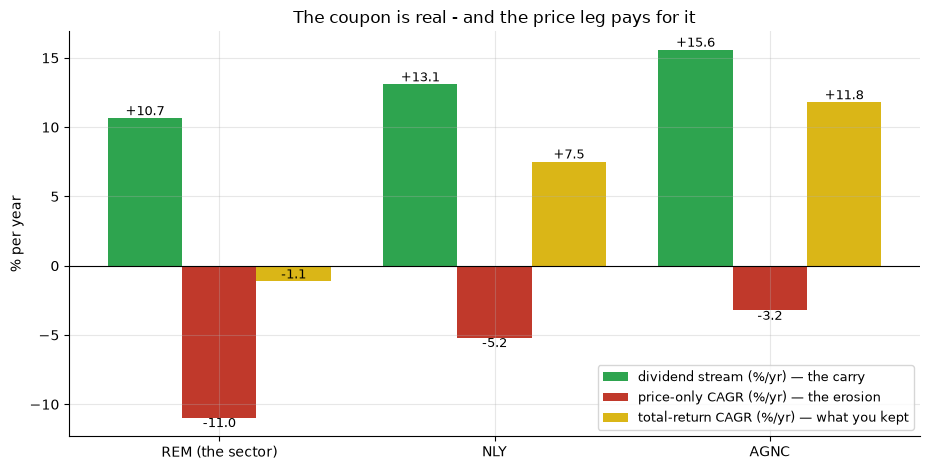

REM: dividend +10.65%/yr  price -10.96%/yr  total -1.13%/yr
NLY: dividend +13.09%/yr  price -5.18%/yr  total +7.52%/yr
AGNC: dividend +15.59%/yr  price -3.22%/yr  total +11.80%/yr


In [3]:
names = ['REM', 'NLY', 'AGNC']
if HAVE_REAL:
    rows = []
    for nm in names:
        mtr, mpx = st.aligned_monthly(TR, PX, [nm, 'IEF', 'SPY', 'BIL'])
        dd = st.decompose(mtr, mpx, nm)
        rows.append((dd['div_ann_pct'], dd['px_cagr_pct'], dd['tr_cagr_pct']))
else:
    rows = [(R['decomp'][nm][2], R['decomp'][nm][5], R['decomp'][nm][4]) for nm in names]
x = np.arange(len(names)); wdt = 0.27
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.bar(x - wdt, [r[0] for r in rows], wdt, color=GREEN, label='dividend stream (%/yr) — the carry')
ax.bar(x,       [r[1] for r in rows], wdt, color=RED, label='price-only CAGR (%/yr) — the erosion')
ax.bar(x + wdt, [r[2] for r in rows], wdt, color=AMBER, label='total-return CAGR (%/yr) — what you kept')
for i, r in enumerate(rows):
    ax.annotate(f'{r[0]:+.1f}', (i - wdt, r[0]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{r[1]:+.1f}', (i, r[1]), ha='center', va='top', fontsize=9)
    ax.annotate(f'{r[2]:+.1f}', (i + wdt, r[2]), ha='center', va='bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['REM (the sector)', 'NLY', 'AGNC'])
ax.set_ylabel('% per year'); ax.legend(fontsize=9)
ax.set_title('The coupon is real - and the price leg pays for it')
plt.tight_layout(); plt.show()
for nm, r in zip(names, rows):
    print(f'{nm}: dividend {r[0]:+.2f}%/yr  price {r[1]:+.2f}%/yr  total {r[2]:+.2f}%/yr')

Every name pays a double-digit real coupon (**+10.7%** to **+15.6%** a year) and every name's *price* erodes (−3 to −11%/yr). The sector fund — the only number free of survivor luck — nets out **negative**. The two survivors netted positive precisely because they're the two that survived; the graveyard (Thornburg, the 2020 margin-call cohort…) is inside REM's red bar.

**And the "real drawdowns" half of the pitch?** Understated, if anything. Here is the "income sleeve" in the four storms of its life, next to the stock market:

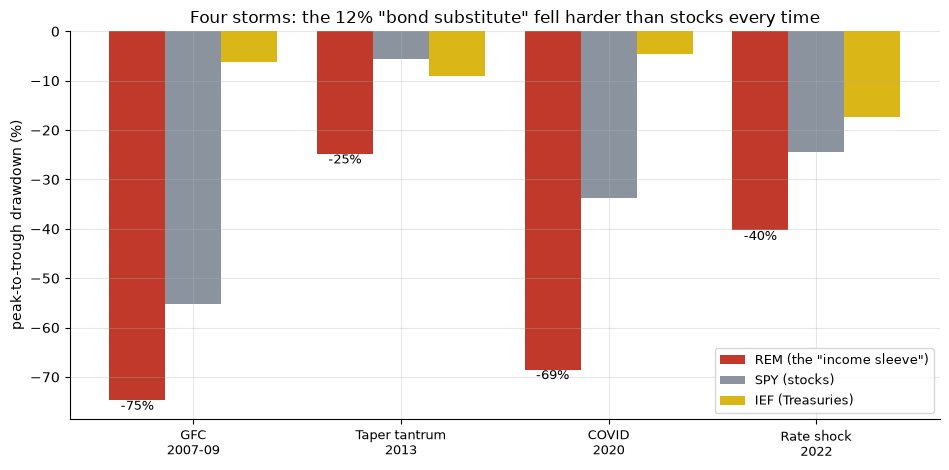

REM drawdowns: ['-74.7%', '-24.8%', '-68.5%', '-40.3%']


In [4]:
labels = [c[0] for c in R['crises']]
if HAVE_REAL:
    ct = st.crisis_table(TR, ['REM', 'SPY', 'IEF'])
    rem, spy, ief = ct['REM'].tolist(), ct['SPY'].tolist(), ct['IEF'].tolist()
else:
    rem = [c[1] for c in R['crises']]; spy = [c[4] for c in R['crises']]; ief = [c[5] for c in R['crises']]
x = np.arange(len(labels)); wdt = .27
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.bar(x - wdt, rem, wdt, color=RED, label='REM (the "income sleeve")')
ax.bar(x,       spy, wdt, color=GREY, label='SPY (stocks)')
ax.bar(x + wdt, ief, wdt, color=AMBER, label='IEF (Treasuries)')
for i in range(len(labels)):
    ax.annotate(f'{rem[i]:.0f}%', (i - wdt, rem[i]), ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([l.replace(' 2', '\n2') for l in labels], fontsize=9)
ax.set_ylabel('peak-to-trough drawdown (%)')
ax.set_title('Four storms: the 12% "bond substitute" fell harder than stocks every time')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print('REM drawdowns:', [f'{v:.1f}%' for v in rem])

**−74.7%** in the GFC (worse than banks' index-level fall), **−68.5% in eight weeks** in March 2020, **−40%** in 2022 — and in 2013 it managed −25% while the stock market barely noticed. Why always? Because the carry is funded with overnight repo: when markets panic, the *lenders* call the loans, and the fund sells its bonds into the crash. The dividend machine is short exactly the thing that disappears in a crisis — liquidity.

## 5 · The verdict

- **Signal — Real.** The carry exists, spectacularly: **10.7%/yr** of hard dividend cash on the sector fund for 19 years (statistically one of the most solid numbers on this desk), 13-16% on the flagships. The pitch's numbers are honest.
- **Tradability — Mirage.** Harvesting that coupon left you with **$80** per $100 — below T-bills — at 24% volatility and a −67% drawdown, and ~10%/yr behind a simple DIY Treasuries+stocks mix with the same measured risk. A worse bond, a worse stock, a worse carry trade.
- **"10-14% free lunch"? — Busted.** The coupon was financed by the price leg (**-11%/yr**; $100 of capital → **$11**). Spend the dividend and you are eating your principal — with a margin call attached.

## 6 · Going further 🚪

- **The family pattern.** Pipelines ([341](../../341-mlp-pipelines/README.md)), BDCs ([342](../../342-bdc-yield/README.md)), and now mortgage REITs: package a levered risk premium, label the payout "income," and let the NAV quietly pay for it. When you see a double-digit yield, the first question is never *"is it real?"* — it usually is — but *"what is it liquidating to pay me?"*
- **The survivor illusion.** NLY and AGNC netting positive is exactly what a graveyard looks like from above: judge sectors by their index fund, not by the names still on the screen.
- **The honest version of the trade.** If you want levered bond carry, the quants notebook shows what a duration-matched Treasuries position actually earned — more, with a third of the drawdown. The carry wasn't the mistake; the *wrapper* was.

*Think the coupon can outrun the erosion — maybe post-2022, with fatter MBS spreads? The engine is in [`mreit_carry/`](../mreit_carry/); re-run `examples/verify.py` on any window and watch the alpha, not the yield.*